In [1]:
!pip install torch torch_geometric

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.0 MB/s  0:00:00
  Attempting uninstall: psutil
    Found existing installation: psutil 5.2.2
    Uninstalling psutil-5.2.2:
      Successfully uninstalled psutil-5.2.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [torch_geometric] [torch_geometric]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
azureml-automl-dnn-nlp 1.61.0 requires torch==2.2.2, but you have torch 2.9.1 which is incompatible.
azureml-automl-runtime 1.61.0 requires psutil<5.9.4,>=5.2.2, but you have psutil 7.2.2 which is incompatible.
azureml-training-tabular 1.61.0 requires psutil<5.9.4,>=5.2.2, but you have psutil 7.2.2 which is incompatible.
azureml-training-tabular 1.61.0 requires scipy<1.11.0,>=1.0.0, but you have scipy 1.11.0 which is incompatible.
jupyter-resource-usage 0.7.2 requires psutil~=5.6, but you have psutil 7.2.2 whi

In [3]:
!pip install torch torch_geometric

In [4]:
import torch
import torch_geometric
print(f"PyTorch version: {torch.__version__}")
print(f"PyTorch Geometric version: {torch_geometric.__version__}")

ModuleNotFoundError: No module named 'torch'

In [5]:
import sys
!{sys.executable} -m pip install torch torch_geometric

  Using cached torch_geometric-2.8.0-py3-none-any.whl.metadata (64 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.1/532.1 MB 55.4 MB/s  0:00:05m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 45.5 MB/s  0:00:06m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 107.8 MB/s  0:00:010:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 108.4 MB/s  0:00:010:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 131.5 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.6/197.6 MB 71.7 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 147.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 41.6 MB/s  0:00:06m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 157.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 118.2 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 7

In [1]:
import torch
import torch_geometric
print(f"PyTorch version: {torch.__version__}")
print(f"PyTorch Geometric version: {torch_geometric.__version__}")

/anaconda/envs/jupyter_env/lib/python3.10/site-packages/torch/__config__.py:9: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._show_config()


PyTorch version: 2.12.1+cu130
PyTorch Geometric version: 2.8.0


In [31]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.datasets import Planetoid
import torch_geometric.transforms as T

# 1. デバイスの自動設定（GPUがあればGPUを使用）
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. サンプルデータの読み込み (Coraデータセット)
dataset = Planetoid(root='/tmp/Cora', name='Cora', transform=T.NormalizeFeatures())
data = dataset[0].to(device)

# 3. GNNモデルの定義
class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(dataset.num_features, 16)
        self.conv2 = GCNConv(16, dataset.num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

# モデルと最適化手法の準備
model = GCN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

# 4. 学習ループ
model.train()
for epoch in range(200):
    optimizer.zero_grad()
    out = model(data)
    # 学習用ノードのみで損失計算
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    
    if epoch % 20 == 0:
        print(f'Epoch {epoch:03d}, Loss: {loss.item():.4f}')

# 5. テスト評価
model.eval()
pred = model(data).argmax(dim=1)
correct = (pred[data.test_mask] == data.y[data.test_mask]).sum()
acc = int(correct) / int(data.test_mask.sum())
print(f'Accuracy: {acc:.4f}')

Epoch 000, Loss: 1.9462
Epoch 020, Loss: 1.6920
Epoch 040, Loss: 1.2669
Epoch 060, Loss: 0.8641
Epoch 080, Loss: 0.6094
Epoch 100, Loss: 0.4433
Epoch 120, Loss: 0.4027
Epoch 140, Loss: 0.3739
Epoch 160, Loss: 0.3250
Epoch 180, Loss: 0.3283
Accuracy: 0.8100


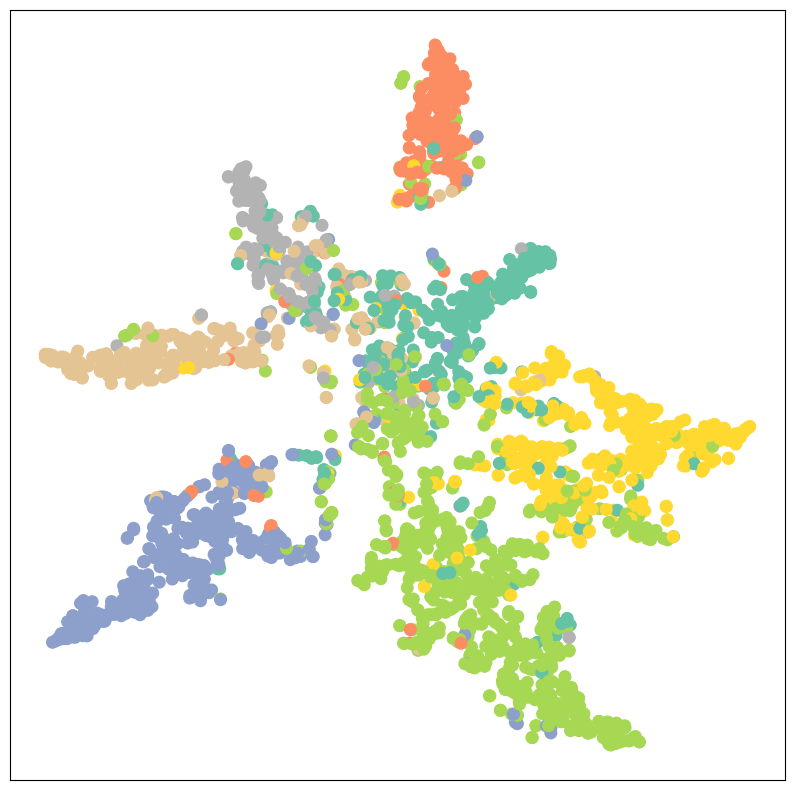

In [16]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def visualize_embeddings(h, color):
    # 埋め込みベクトル（h）をt-SNEで2次元に圧縮
    z = TSNE(n_components=2, random_state=42).fit_transform(h.detach().cpu().numpy())
    
    plt.figure(figsize=(10, 10))
    plt.xticks([])
    plt.yticks([])
    
    # 散布図としてプロット（colorは正解ラベル）
    plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set2")
    plt.show()

# 使い方：モデルの最終層の前（または途中の層）の出力を取得して可視化
model.eval()
out = model(data)  # モデルの出力（対数確率）
# ここでは例として最終出力を使っていますが、実際はReLU前の埋め込みを使うとより綺麗です
visualize_embeddings(out, color=data.y.cpu())

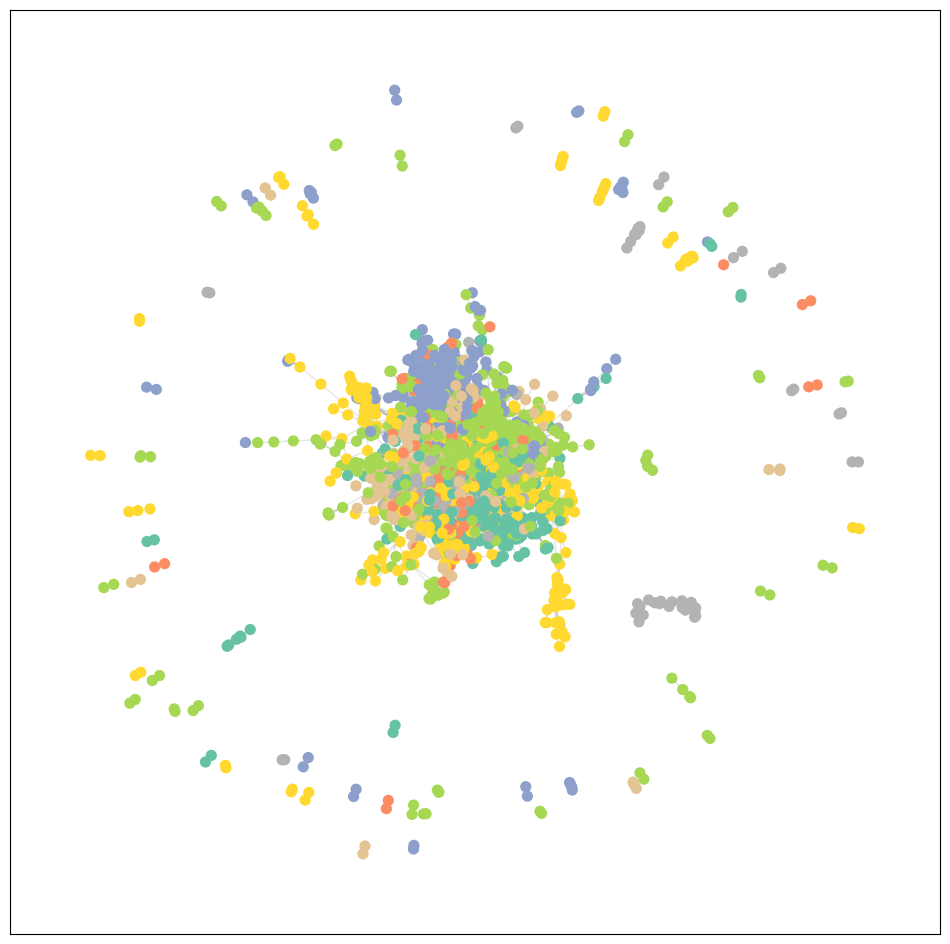

In [17]:
import networkx as nx
from torch_geometric.utils import to_networkx

def plot_graph(data, pred):
    # PyG形式をNetworkX形式に変換
    G = to_networkx(data, to_undirected=True)
    
    plt.figure(figsize=(12, 12))
    pos = nx.spring_layout(G, seed=42)  # ノードの配置を計算
    
    # ノードを予測結果の色で塗る
    nx.draw_networkx_nodes(G, pos, node_size=50, node_color=pred.cpu(), cmap='Set2')
    nx.draw_networkx_edges(G, pos, alpha=0.1)  # エッジを薄く描画
    plt.show()

# 使い方
pred = model(data).argmax(dim=1)
plot_graph(data, pred)

In [37]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.datasets import Planetoid
import torch_geometric.transforms as T
from torch_geometric.nn import GATConv

# 1. デバイスの自動設定（GPUがあればGPUを使用）
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. サンプルデータの読み込み (Coraデータセット)
dataset = Planetoid(root='/tmp/Cora', name='Cora', transform=T.NormalizeFeatures())
data = dataset[0].to(device)

# 3. GNNモデルの定義
# 変更イメージ

class GAT(torch.nn.Module):
    def __init__(self):
        super().__init__()
        # headsはAttentionの数
        self.conv1 = GATConv(dataset.num_features, 8, heads=8) 
        self.conv2 = GATConv(8 * 8, dataset.num_classes, heads=1)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.dropout(x, p=0.6, training=self.training)
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

# モデルと最適化手法の準備
model = GAT().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

# 1. 学習ループに入る前に「ベストモデルを保持する変数」を定義
best_loss = float('inf')
best_model_state = None

# 4. 学習ループ
model.train()
for epoch in range(200):
    optimizer.zero_grad()
    out = model(data)
    # 学習用ノードのみで損失計算
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    
    if epoch % 20 == 0:
        print(f'Epoch {epoch:03d}, Loss: {loss.item():.4f}')
# --- この後に「5. テスト評価」へ進む ---

# 5. テスト評価
model.eval()
pred = model(data).argmax(dim=1)
correct = (pred[data.test_mask] == data.y[data.test_mask]).sum()
acc = int(correct) / int(data.test_mask.sum())
print(f'Accuracy: {acc:.4f}')

Epoch 000, Loss: 1.9488
Epoch 020, Loss: 1.3075
Epoch 040, Loss: 0.5724
Epoch 060, Loss: 0.3593
Epoch 080, Loss: 0.3074
Epoch 100, Loss: 0.2416
Epoch 120, Loss: 0.2583
Epoch 140, Loss: 0.2446
Epoch 160, Loss: 0.2294
Epoch 180, Loss: 0.2056
Accuracy: 0.8190


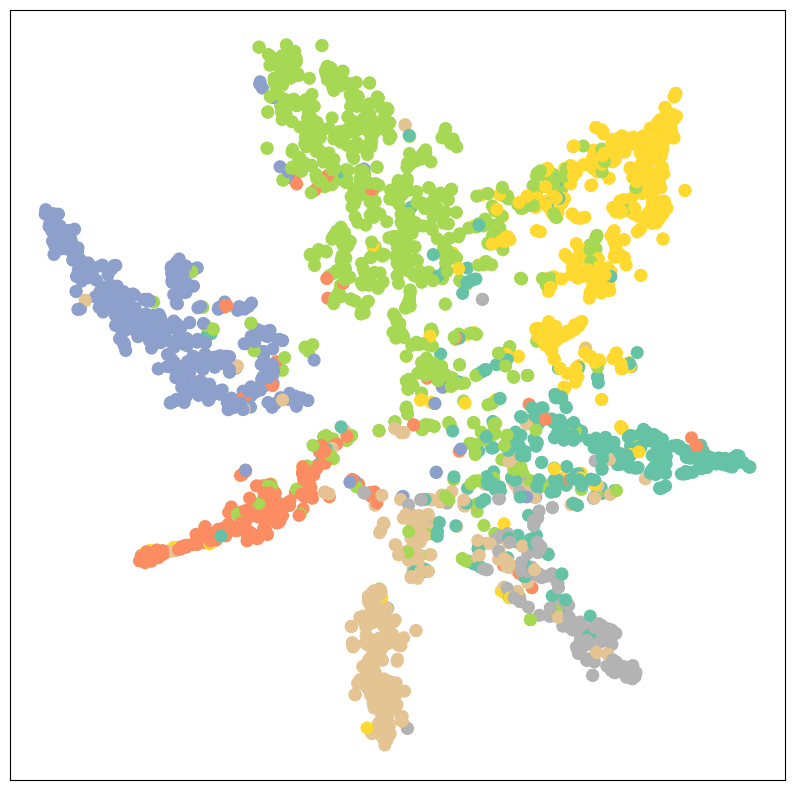

In [38]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def visualize_embeddings(h, color):
    # 埋め込みベクトル（h）をt-SNEで2次元に圧縮
    z = TSNE(n_components=2, random_state=42).fit_transform(h.detach().cpu().numpy())
    
    plt.figure(figsize=(10, 10))
    plt.xticks([])
    plt.yticks([])
    
    # 散布図としてプロット（colorは正解ラベル）
    plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set2")
    plt.show()

# 使い方：モデルの最終層の前（または途中の層）の出力を取得して可視化
model.eval()
out = model(data)  # モデルの出力（対数確率）
# ここでは例として最終出力を使っていますが、実際はReLU前の埋め込みを使うとより綺麗です
visualize_embeddings(out, color=data.y.cpu())

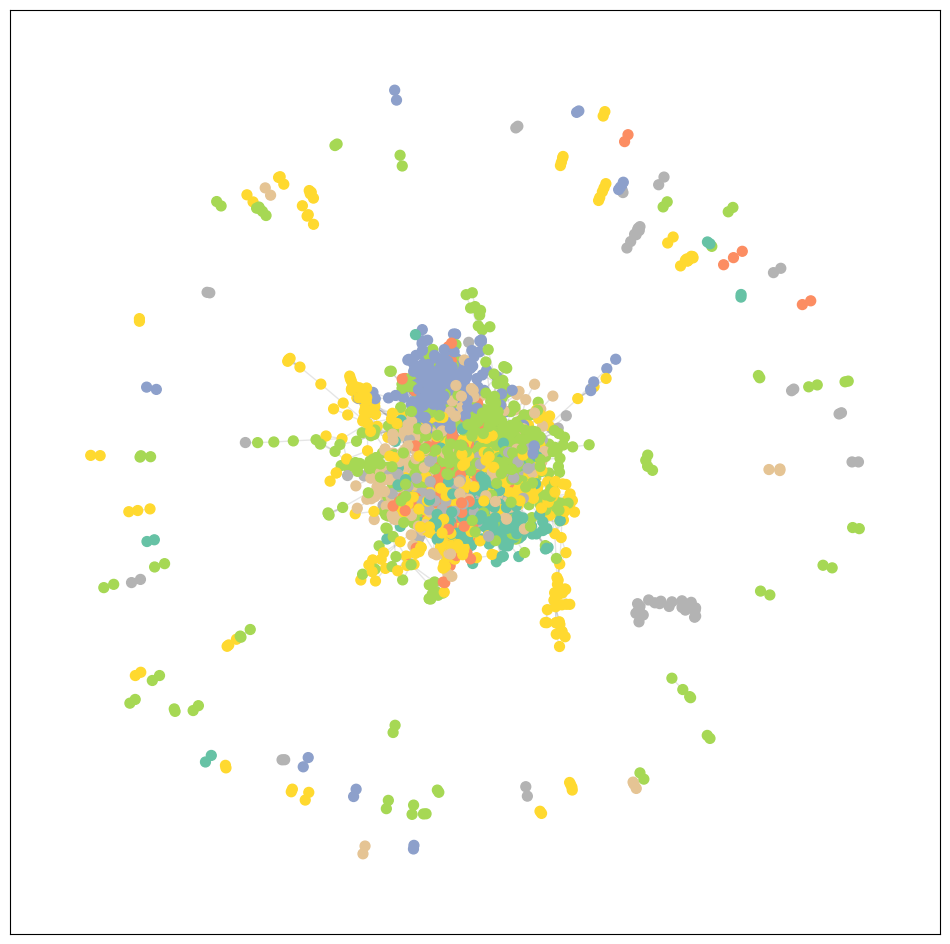

In [39]:
import networkx as nx
from torch_geometric.utils import to_networkx

def plot_graph(data, pred):
    # PyG形式をNetworkX形式に変換
    G = to_networkx(data, to_undirected=True)
    
    plt.figure(figsize=(12, 12))
    pos = nx.spring_layout(G, seed=42)  # ノードの配置を計算
    
    # ノードを予測結果の色で塗る
    nx.draw_networkx_nodes(G, pos, node_size=50, node_color=pred.cpu(), cmap='Set2')
    nx.draw_networkx_edges(G, pos, alpha=0.1)  # エッジを薄く描画
    plt.show()

# 使い方
pred = model(data).argmax(dim=1)
plot_graph(data, pred)